In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Asif117204/knn_project/master/heart_disease.csv"

df = pd.read_csv(url)

print(df.head())

    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0                   No           

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from mlxtend.plotting import plot_decision_regions

In [ ]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Shape:
(10000, 21)

Columns:
Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

Missing Values:
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Suga

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')

df = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

print(df.isnull().sum())

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64


In [ ]:
le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

print(df.head())

   Age  Gender  Blood Pressure  Cholesterol Level  Exercise Habits  Smoking  \
0   38       1              33                  5                0        1   
1   51       0              26                136                0        0   
2   28       1               6                 66                1        0   
3   14       0               2                143                0        1   
4   42       1              46                 92                1        1   

   Family Heart Disease  Diabetes   BMI  High Blood Pressure  ...  \
0                     1         0  3051                    1  ...   
1                     1         1  3164                    0  ...   
2                     0         0  5334                    0  ...   
3                     1         0  2685                    1  ...   
4                     1         1  1083                    1  ...   

   High LDL Cholesterol  Alcohol Consumption  Stress Level  Sleep Hours  \
0                     0            

In [ ]:
X = df.drop('Heart Disease Status', axis=1)

y = df['Heart Disease Status']

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train Shape:", X_train.shape)

print("Validation Shape:", X_val.shape)

print("Test Shape:", X_test.shape)

Train Shape: (7000, 20)
Validation Shape: (1500, 20)
Test Shape: (1500, 20)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

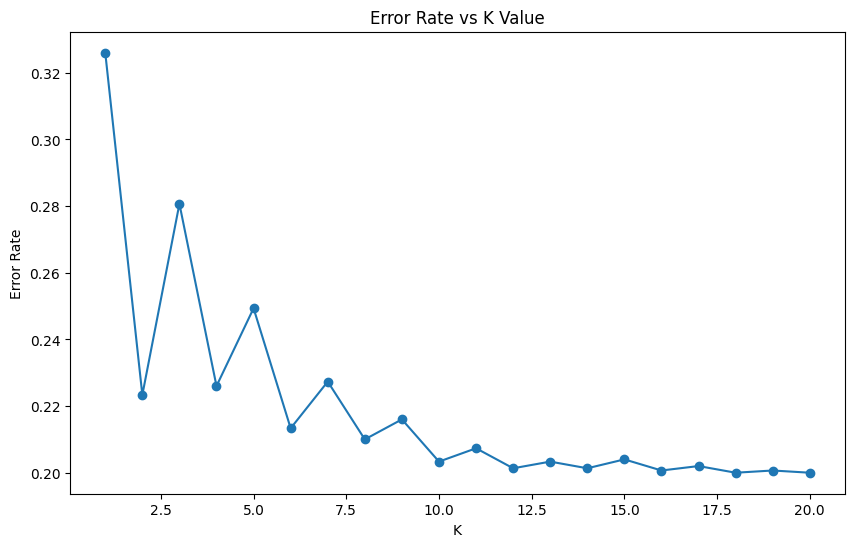

In [ ]:
error_rate = []

for i in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=i)

    knn.fit(X_train, y_train)

    pred_i = knn.predict(X_test)

    error_rate.append(
        np.mean(pred_i != y_test)
    )

plt.figure(figsize=(10,6))

plt.plot(
    range(1,21),
    error_rate,
    marker='o'
)

plt.title("Error Rate vs K Value")

plt.xlabel("K")

plt.ylabel("Error Rate")

plt.show()

In [ ]:
param_grid = {
    'n_neighbors': [3,5,7,9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}


In [ ]:
best_model = grid.best_estimator_

print(best_model)

KNeighborsClassifier(metric='euclidean', n_neighbors=9)


In [ ]:
y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("AUC Score:", auc)

Accuracy: 0.784
Precision: 0.038461538461538464
Recall: 0.0033333333333333335
F1 Score: 0.006134969325153374
AUC Score: 0.5086736111111111


In [ ]:
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.80      0.98      0.88      1200
           1       0.04      0.00      0.01       300

    accuracy                           0.78      1500
   macro avg       0.42      0.49      0.44      1500
weighted avg       0.65      0.78      0.70      1500



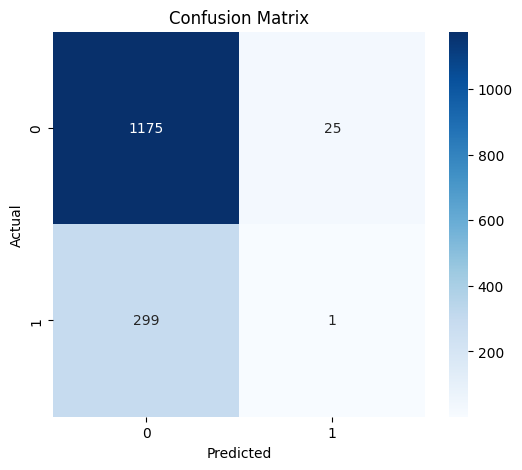

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

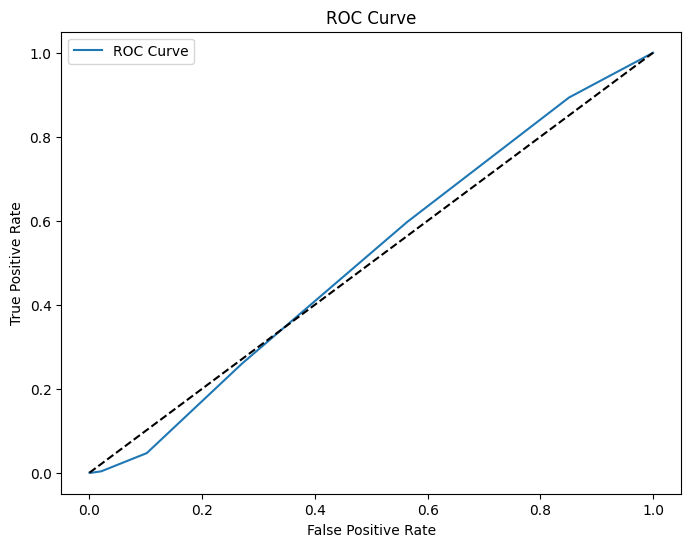

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='ROC Curve')

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
sample_predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Probability': y_prob
})

print(sample_predictions.head(10))

   Actual  Predicted  Probability
0       0          0     0.111111
1       0          0     0.222222
2       0          0     0.111111
3       0          0     0.000000
4       0          0     0.111111
5       0          0     0.000000
6       0          0     0.222222
7       0          0     0.111111
8       1          0     0.222222
9       1          0     0.222222


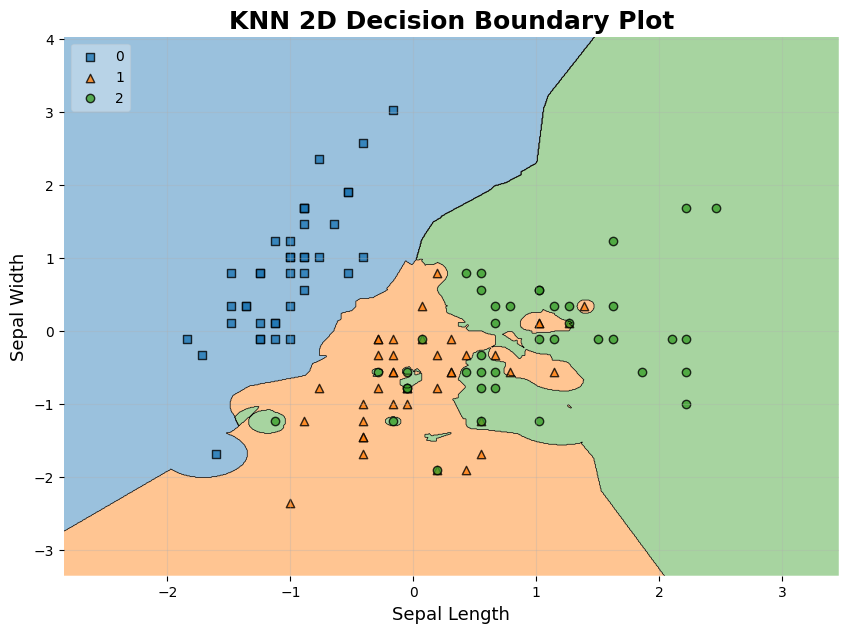

In [ ]:
# =========================================
# PERFECT KNN 2D DECISION BOUNDARY PLOT
# =========================================

import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from mlxtend.plotting import plot_decision_regions

# ---------------------------------
# Load Iris Dataset
# ---------------------------------

iris = load_iris()

# Take only first 2 features
X = iris.data[:, :2]

# Target
y = iris.target

# ---------------------------------
# Train Test Split
# ---------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------------------------
# Feature Scaling
# ---------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# ---------------------------------
# Train KNN Model
# ---------------------------------

knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='euclidean'
)

knn.fit(X_train, y_train)

# ---------------------------------
# Plot Decision Boundary
# ---------------------------------

plt.figure(figsize=(10,7))

plot_decision_regions(
    X_train,
    y_train,
    clf=knn,
    legend=2
)

# ---------------------------------
# Beautify Plot
# ---------------------------------

plt.title(
    "KNN 2D Decision Boundary Plot",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    "Sepal Length",
    fontsize=13
)

plt.ylabel(
    "Sepal Width",
    fontsize=13
)

plt.xticks(fontsize=10)

plt.yticks(fontsize=10)

plt.grid(alpha=0.3)

plt.show()